## Import thư viện

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

## Đọc dữ liệu

In [36]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra dữ liệu

In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100853 entries, 0 to 100852
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  100853 non-null  object 
 1   order_purchase_timestamp  100853 non-null  object 
 2   price                     100853 non-null  float64
 3   freight_value             100853 non-null  float64
 4   payment_value             100853 non-null  float64
 5   order_status              100853 non-null  object 
 6   seller_id                 100853 non-null  object 
 7   customer_unique_id        100853 non-null  object 
 8   customer_city             100853 non-null  object 
 9   customer_state            100853 non-null  object 
 10  product_category_name     100853 non-null  object 
 11  Category_VN               100853 non-null  object 
 12  product_id                100853 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.0

,price,freight_value,payment_value
count,100853.000000,100853.000000,100853.000000
mean,120.008066,19.853701,179.894830
std,180.412420,15.469460,273.820426
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.700000
50%,74.900000,16.190000,114.450000
75%,134.640000,21.020000,195.120000
max,6735.000000,409.680000,13664.080000


## Kiểm tra và xử lý dữ liệu thiếu

In [38]:
df.isnull().sum()
df = df.dropna()

## Chuyển cột thời gian sang dạng datetime

In [39]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

## Tổng hợp doanh thu theo ngày

In [40]:
df_prophet = df.groupby('order_purchase_timestamp')['payment_value'].sum().reset_index()

## Đổi tên cột theo định dạng Prophet
### ds = datetime
### y = value

In [41]:
df_prophet.columns = ['ds','y']

## Khởi tạo mô hình Prophet

In [42]:
model = Prophet()

## Huấn luyện mô hình

In [43]:
model.fit(df_prophet)

21:54:26 - cmdstanpy - INFO - Chain [1] start processing
21:54:31 - cmdstanpy - INFO - Chain [1] done processing


## Tạo dữ liệu dự đoán trong tương lai

In [44]:
future = model.make_future_dataframe(periods=30)

## Dự đoán

In [45]:
forecast = model.predict(future)

## Xem kết quả dự đoán

In [46]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
87765,2018-08-18 23:59:54,169.503271,-659.706434,1008.586131
87766,2018-08-19 23:59:54,169.029800,-616.545342,946.715978
87767,2018-08-20 23:59:54,186.468447,-622.888503,957.024874
87768,2018-08-21 23:59:54,186.572766,-633.541982,1006.051542
87769,2018-08-22 23:59:54,178.928836,-628.475787,1017.774376


## Trực quan hóa dự báo

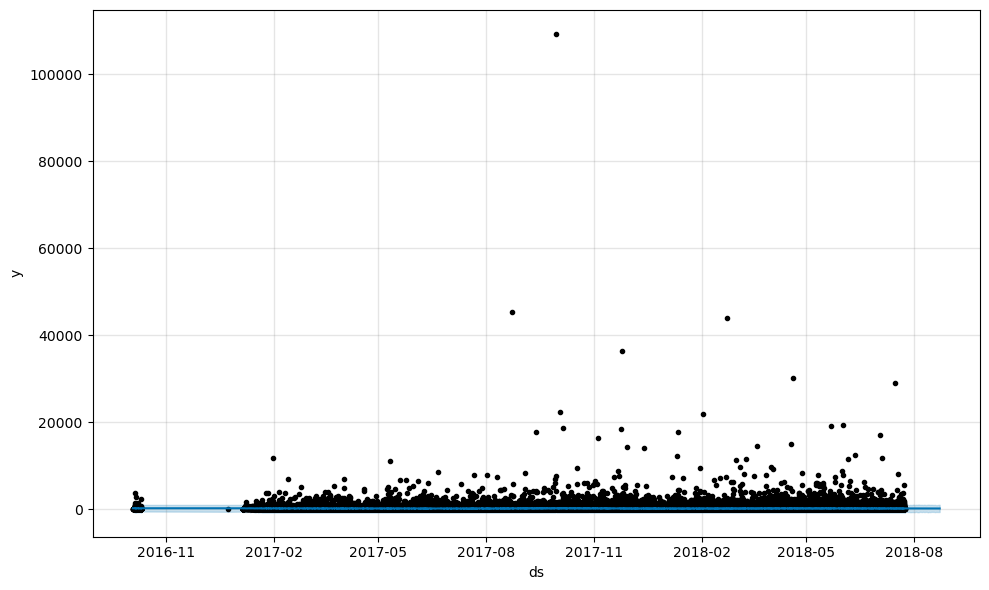

In [47]:
model.plot(forecast)
plt.show()

## Xem các thành phần của dự báo

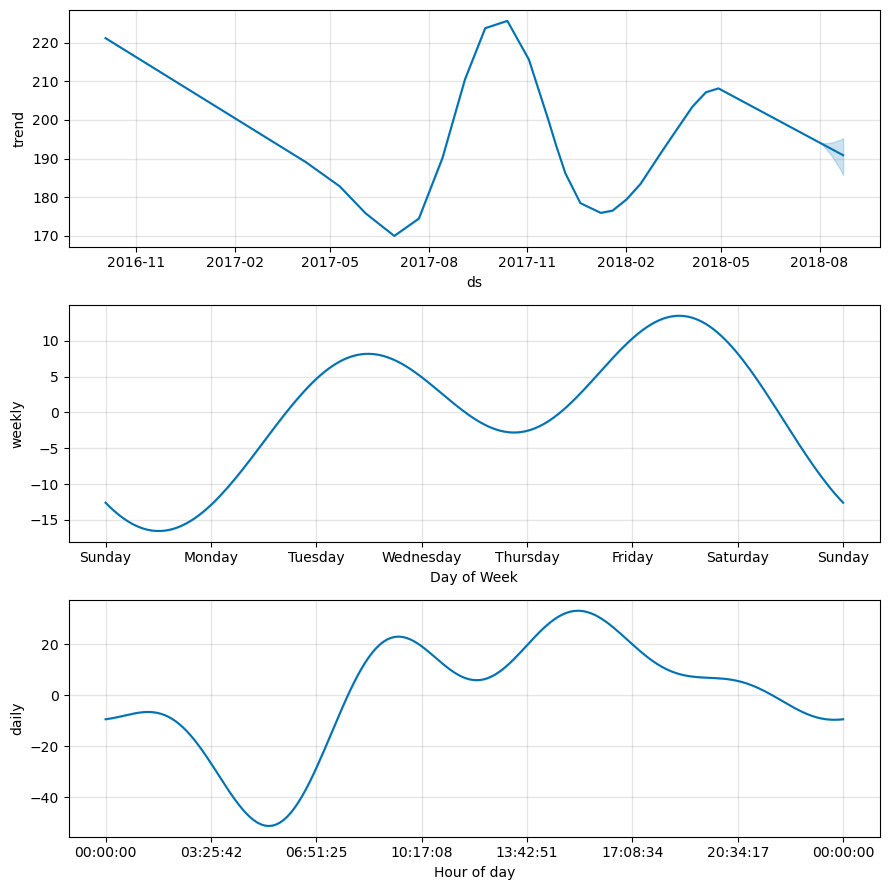

In [48]:
model.plot_components(forecast)
plt.show()

### Lưu model vào file bkl

In [49]:
import pickle

with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [50]:
import pickle

pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/prophet_model.pkl","rb"))